In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

## Celda 2: Carga de Datos y Revisión Inicia

In [12]:
# Cargar los archivos
try:
    df_gdp = pd.read_csv("data_2025/pib2020-2025.csv")
    df_le = pd.read_csv("data_2025/WHO_life_expectancy.csv")
except FileNotFoundError:
    print("Asegúrate de que los archivos 'pib2020-2025.csv' y 'WHO_life_expectancy.csv' estén en el directorio.")
    # Si los archivos no se encuentran, el resto del código fallará.
    # En un entorno real, aquí se detendría la ejecución.

print("\n--- Primeras filas de PIB ---")
print(df_gdp.head())
print("\n--- Información de Esperanza de Vida ---")
df_le.info()


--- Primeras filas de PIB ---
       Country    2020      2021      2022      2023      2024      2025
0  Afghanistan   20136   14278.0   14501.0   17248.0       NaN       NaN
1      Albania   15271   18086.0   19185.0   23388.0   27259.0   28372.0
2      Algeria  164774  185850.0  225709.0  247789.0  264913.0  268885.0
3      Andorra    2885    3325.0    3376.0    3786.0    4038.0    4035.0
4       Angola   66521   84375.0  142442.0  109764.0  115946.0  113343.0

--- Información de Esperanza de Vida ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        24420 non-null  object
 1   Indicator            24420 non-null  object
 2   ParentLocationCode   24420 non-null  object
 3   ParentLocation       24420 non-null  object
 4   Location type        24420 non-null  object
 5   SpatialDimValueCode  24420 non-n

## Celda 3: Limpieza y Transformación de la Esperanza de Vida (LE)

In [13]:
# 1. Filtrar por 'Life expectancy at birth (years)' y 'Both sexes'
df_le_filtered = df_le[
    (df_le['Indicator'] == 'Life expectancy at birth (years)') &
    (df_le['Dim1'] == 'Both sexes')
].copy()

# 2. Extraer el valor numérico (eliminar el intervalo de confianza '[...]' )
df_le_filtered['Life Expectancy'] = df_le_filtered['Value'].str.split(' ').str[0]

# 3. Seleccionar y renombrar columnas
df_le_cleaned = df_le_filtered.rename(
    columns={'Location': 'Country', 'Period': 'Year'}
)[['Country', 'Year', 'Life Expectancy']]

# 4. Conversión de tipos de datos
df_le_cleaned['Life Expectancy'] = pd.to_numeric(df_le_cleaned['Life Expectancy'], errors='coerce')
df_le_cleaned['Year'] = df_le_cleaned['Year'].astype(int)

print("--- Esperanza de Vida Limpia ---")
print(df_le_cleaned.head())

--- Esperanza de Vida Limpia ---
                     Country  Year  Life Expectancy
2                    Lesotho  2021             51.5
5   Central African Republic  2021             52.3
6                    Somalia  2021             54.0
8                   Eswatini  2021             54.6
18                Mozambique  2021             57.7


## Celda 4: Transformación del PIB (GDP) y Fusión de Datasets

In [14]:
# 1. Transformar PIB de formato 'ancho' a 'largo' (melt)
df_gdp_melted = df_gdp.melt(
    id_vars='Country',
    value_vars=[col for col in df_gdp.columns if col.isdigit()],
    var_name='Year',
    value_name='GDP'
)
df_gdp_melted['Year'] = pd.to_numeric(df_gdp_melted['Year'], errors='coerce').astype('Int64')
df_gdp_melted['GDP'] = pd.to_numeric(df_gdp_melted['GDP'], errors='coerce')

# 2. Fusión de datos por 'Country' y 'Year'
df_merged = pd.merge(
    df_gdp_melted,
    df_le_cleaned,
    on=['Country', 'Year'],
    how='inner' 
)

# 3. Limpieza final: eliminar NaNs y resetear índice
df_final = df_merged.dropna().reset_index(drop=True)

# 4. Aplicar transformación logarítmica al PIB (Log(1+x)) para manejar la alta dispersión
df_final['log_GDP'] = np.log1p(df_final['GDP'])

print(f"Dimensiones del dataset final: {df_final.shape}")
print("\n--- Dataset Final --- ")
df_final.head()

Dimensiones del dataset final: (321, 5)

--- Dataset Final --- 


,Country,Year,GDP,Life Expectancy,log_GDP
0,Afghanistan,2020,20136.0,60.5,9.910314
1,Albania,2020,15271.0,76.5,9.633776
2,Algeria,2020,164774.0,74.0,12.012336
3,Angola,2020,66521.0,62.6,11.105288
4,Antigua and Barbuda,2020,1412.0,77.6,7.253470


## Celda 5: Creación de Variable Target de Clasificación

In [15]:
# Creación de una variable binaria usando la media como umbral
mean_le = df_final['Life Expectancy'].mean()

df_final['LE_Class'] = df_final['Life Expectancy'].apply(
    lambda x: 1 if x > mean_le else 0
)

print(f"Media de Esperanza de Vida: {mean_le:.2f} años")
print("Conteo de la clase:\n", df_final['LE_Class'].value_counts())

# Guardamos el dataset final con la nueva columna de clase
df_final.to_csv('cleaned_data_for_modeling.csv', index=False)

Media de Esperanza de Vida: 71.52 años
Conteo de la clase:
 LE_Class
1    174
0    147
Name: count, dtype: int64


## Celda 6: Estadísticas Descriptivas (Parte del EDA)

In [16]:
print("--- Estadísticas Descriptivas --- ")
df_final[['GDP', 'Life Expectancy', 'log_GDP']].describe()

--- Estadísticas Descriptivas --- 


,GDP,Life Expectancy,log_GDP
count,3.210000e+02,321.000000,321.000000
mean,3.664041e+05,71.520561,10.676503
std,1.458291e+06,7.324817,2.105473
min,2.220000e+02,51.500000,5.407172
25%,1.222200e+04,66.100000,9.411075
50%,3.820900e+04,72.600000,10.550853
75%,2.105410e+05,76.800000,12.257440
max,1.819080e+07,84.700000,16.716427


## Celda 7: Visualización de Distribuciones y Relación (Parte del EDA)

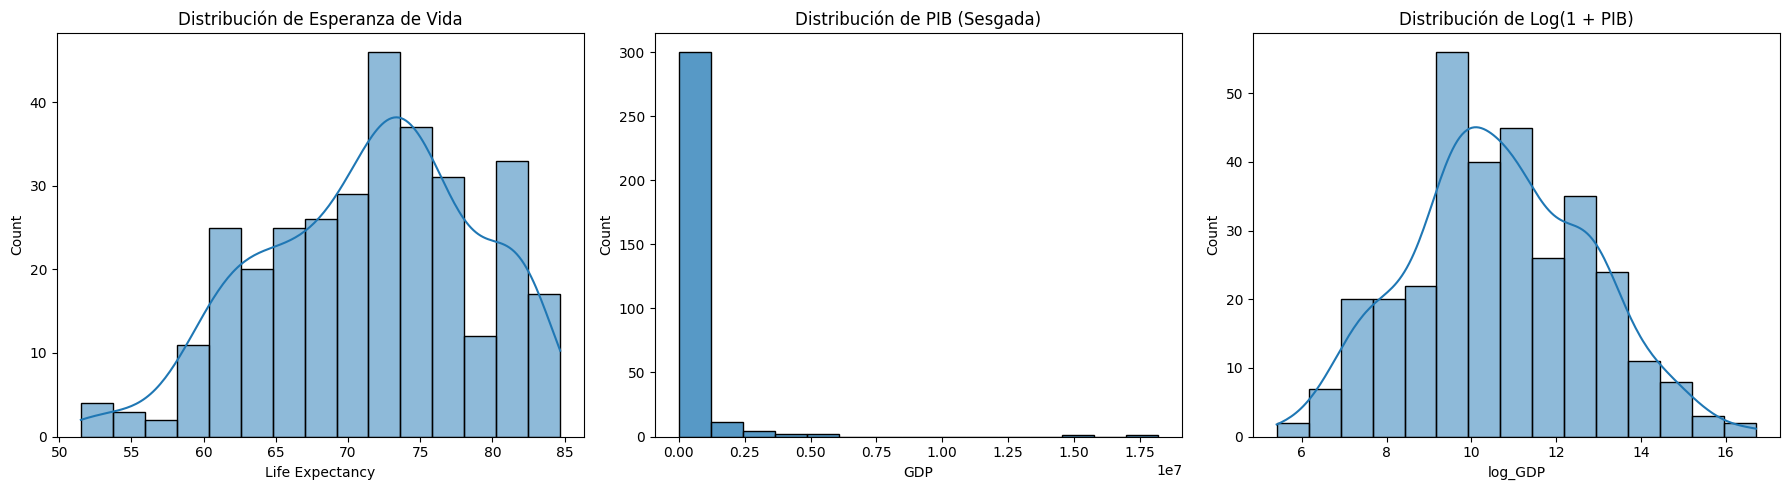

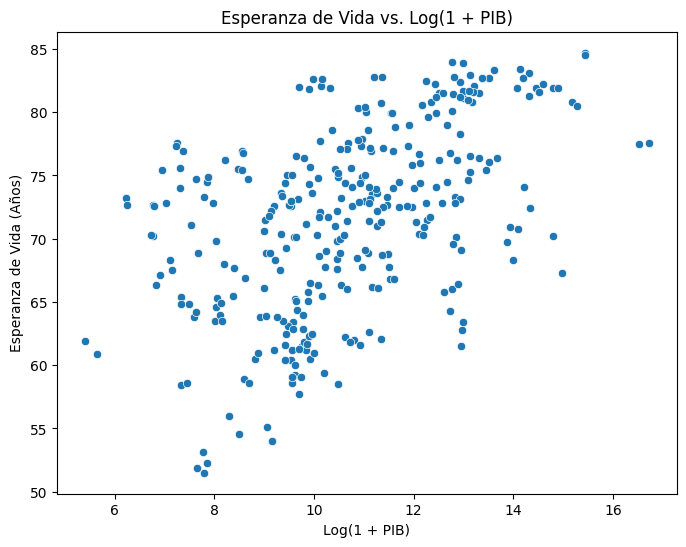

In [17]:
# Gráfico 1: Distribuciones
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_final['Life Expectancy'], kde=True, bins=15)
plt.title('Distribución de Esperanza de Vida')

plt.subplot(1, 3, 2)
sns.histplot(df_final['GDP'], bins=15)
plt.title('Distribución de PIB (Sesgada)')

plt.subplot(1, 3, 3)
sns.histplot(df_final['log_GDP'], kde=True, bins=15)
plt.title('Distribución de Log(1 + PIB)')

plt.tight_layout()
plt.show()

# Gráfico 2: Scatter Plot de la Relación
plt.figure(figsize=(8, 6))
sns.scatterplot(x='log_GDP', y='Life Expectancy', data=df_final)
plt.title('Esperanza de Vida vs. Log(1 + PIB)')
plt.xlabel('Log(1 + PIB)')
plt.ylabel('Esperanza de Vida (Años)')
plt.show()

## Celda 8: Preparación de Datos para Modelado

In [18]:
# Variables para Regresión
X = df_final[['log_GDP']]
y = df_final['Life Expectancy']

# Variables para Clasificación
X_class = df_final[['log_GDP']]
y_class = df_final['LE_Class']

# División de datos (Regresión)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# División de datos (Clasificación - estratificada)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42, stratify=y_class
)

# Escalado de características (Necesario para KNN y buenas prácticas en general)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_class = StandardScaler()
X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

## Celda 9: Modelos de Regresión (Lineal, KNN, Decision Tree)


In [19]:
results = {}

# --- Regresión Lineal ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
results['Regresión Lineal'] = {
    'R2': r2_score(y_test, lr_pred),
    'MSE': mean_squared_error(y_test, lr_pred)
}

# --- K-Nearest Neighbors (KNN) Regressor ---
knn_model = KNeighborsRegressor(n_neighbors=5) # k=5 es un valor común
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
results['KNN Regressor'] = {
    'R2': r2_score(y_test, knn_pred),
    'MSE': mean_squared_error(y_test, knn_pred)
}

# --- Decision Tree Regressor ---
dt_model = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
results['Decision Tree Regressor'] = {
    'R2': r2_score(y_test, dt_pred),
    'MSE': mean_squared_error(y_test, dt_pred)
}

print("\n--- Resultados de Regresión ---")
for model, metrics in results.items():
    print(f"\n{model}:")
    print(f"  R-squared (R²): {metrics['R2']:.4f}")
    print(f"  Mean Squared Error (MSE): {metrics['MSE']:.4f}")


--- Resultados de Regresión ---

Regresión Lineal:
  R-squared (R²): 0.1446
  Mean Squared Error (MSE): 35.2490

KNN Regressor:
  R-squared (R²): -0.1417
  Mean Squared Error (MSE): 47.0458

Decision Tree Regressor:
  R-squared (R²): 0.0292
  Mean Squared Error (MSE): 40.0049


## Celda 10: Modelo de Clasificación (Regresión Logística)

In [20]:
# Inicializar y entrenar el modelo de Regresión Logística
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(X_train_class_scaled, y_train_class)

# Predecir y evaluar
logreg_pred = logreg_model.predict(X_test_class_scaled)

accuracy = accuracy_score(y_test_class, logreg_pred)
precision = precision_score(y_test_class, logreg_pred)
recall = recall_score(y_test_class, logreg_pred)
f1 = f1_score(y_test_class, logreg_pred)
matriz_confusion = confusion_matrix(y_test_class, logreg_pred)

class_report = classification_report(y_test_class, logreg_pred, target_names=['Baja LE (0)', 'Alta LE (1)'])

print("\n--- Regresión Logística (Clasificación) ---")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Exhaustividad (Recall): {recall:.4f}")
print(f"Puntuación F1 (F1 Score): {f1:.4f}")
print("Matriz de Confusión:")
print(matriz_confusion)
print("\nInforme de Clasificación:")
print(class_report)


--- Regresión Logística (Clasificación) ---
Exactitud (Accuracy): 0.6907
Precisión (Precision): 0.7091
Exhaustividad (Recall): 0.7358
Puntuación F1 (F1 Score): 0.7222
Matriz de Confusión:
[[28 16]
 [14 39]]

Informe de Clasificación:
              precision    recall  f1-score   support

 Baja LE (0)       0.67      0.64      0.65        44
 Alta LE (1)       0.71      0.74      0.72        53

    accuracy                           0.69        97
   macro avg       0.69      0.69      0.69        97
weighted avg       0.69      0.69      0.69        97

